# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

LabelEncoder convierte cada categoria en un numero y guarda el resultado en una sola columna. OneHotEncoder crea una columna diferente para cada categoria y marca con 1 o 0 cual corresponde. OneHotEncoder evita que el modelo crea que una categoria vale mas que otra, aunque genera más columnas.

In [8]:
print("Resultado de LabelEncoder:")
display(
    data[["sex", "sex_label"]].drop_duplicates()
)

print("Resultado de OneHotEncoder:")
display(
    data[
        ["embarked", "embarked_C", "embarked_Q", "embarked_S"]
    ].drop_duplicates()
)

Resultado de LabelEncoder:


,sex,sex_label
0,male,1
1,female,0


Resultado de OneHotEncoder:


,embarked,embarked_C,embarked_Q,embarked_S
0,S,False,False,True
1,C,True,False,False
5,Q,False,True,False
61,NaN,False,False,False


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

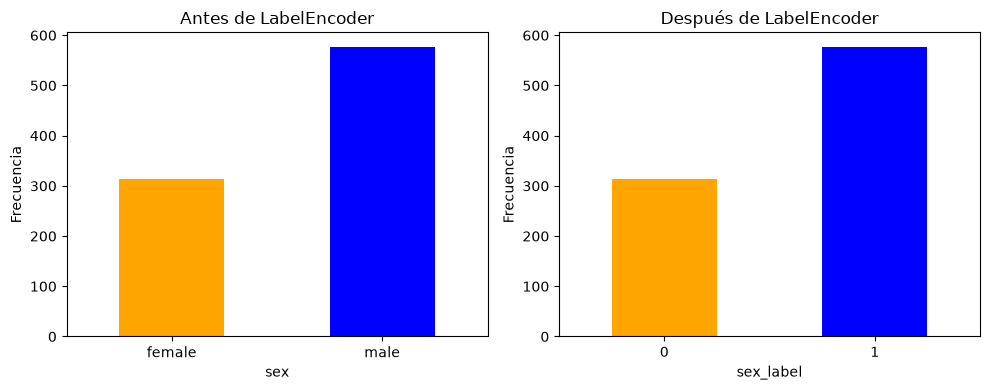

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

data["sex"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    color=["orange", "blue"]
)
axes[0].set_title("Antes de LabelEncoder")
axes[0].set_xlabel("sex")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis="x", rotation=0)

data["sex_label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    color=["orange", "blue"]
)
axes[1].set_title("Después de LabelEncoder")
axes[1].set_xlabel("sex_label")
axes[1].set_ylabel("Frecuencia")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

OneHotEncoder crea una columna diferente para cada clase y marca con 1 la que corresponde y con 0 las demas. La ventaja frente a LabelEncoder es que no asigna un valor numerico que pueda hacerle creer al modelo que una categoria vale más que otra. Aunque tambien tiene la desventaja de crear más columnas.

In [10]:
codificador_class = OneHotEncoder(
    sparse_output=False,
    dtype=int
)

class_codificada = codificador_class.fit_transform(
    data[["class"]]
)

nombres_columnas = codificador_class.get_feature_names_out(
    ["class"]
)

class_onehot = pd.DataFrame(
    class_codificada,
    columns=nombres_columnas,
    index=data.index
)

resultado_class = pd.concat(
    [data[["class"]], class_onehot],
    axis=1
)

resultado_class.head(10)

,class,class_First,class_Second,class_Third
0,Third,0,0,1
1,First,1,0,0
2,Third,0,0,1
3,First,1,0,0
4,Third,0,0,1
5,Third,0,0,1
6,First,1,0,0
7,Third,0,0,1
8,Third,0,0,1
9,Second,0,1,0


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

Yo elegiria OneHotEncoder porque crea una columna para cada categoria y asi el modelo no cree que una categoria vale más que otra. Lo usaria para variables como sex, embarked y class. La desventaja es que genera más columnas, pero la informacion queda mejor representada para entrenar el modelo.

In [11]:
variables_categoricas = ["sex", "embarked", "class"]

codificador_modelo = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    dtype=int
)

datos_codificados = codificador_modelo.fit_transform(
    data[variables_categoricas]
)

datos_codificados = pd.DataFrame(
    datos_codificados,
    columns=codificador_modelo.get_feature_names_out(
        variables_categoricas
    ),
    index=data.index
)

datos_codificados.head()

,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_nan,class_First,class_Second,class_Third
0,0,1,0,0,1,0,0,0,1
1,1,0,1,0,0,0,1,0,0
2,1,0,0,0,1,0,0,0,1
3,1,0,0,0,1,0,1,0,0
4,0,1,0,0,1,0,0,0,1
